In [21]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torchvision
import omegaconf
import random

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from models.ired import IREDEnergy
from ebm.ired import IREDTrainer

CHECKPOINT = "../../checkpoints/ired.pth"
DEVICE = "cuda"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
conf = omegaconf.OmegaConf.load("../config/conf.yaml")

energy_model = IREDEnergy(conf)
trainer = IREDTrainer(energy_model, conf)

state = torch.load(CHECKPOINT, map_location=DEVICE)
trainer.load_state_dict(state)
trainer.to(DEVICE)
trainer.eval()

print(trainer)
print(f"\nSigma schedule (coarse→fine): {trainer.sigmas.tolist()}")

IREDTrainer(
  (model): IREDEnergy(
    (conv_trunk): Sequential(
      (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(2, 2), padding=(4, 4))
      (1): Swish()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): Swish()
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): Swish()
      (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): Swish()
      (8): Flatten(start_dim=1, end_dim=-1)
      (9): Linear(in_features=256, out_features=64, bias=True)
      (10): Swish()
    )
    (k_embedding): Embedding(30, 10)
    (energy_head): Sequential(
      (0): Linear(in_features=84, out_features=64, bias=True)
      (1): Swish()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)

Sigma schedule (coarse→fine): [0.949999988079071, 0.9472448229789734, 0.9390116333961487, 0.9253970384597778, 0.9065604209899902, 0.8827229142189026, 0.8541637659072876, 0.8212178349494934, 0.784

torch.Size([16, 1, 28, 28])


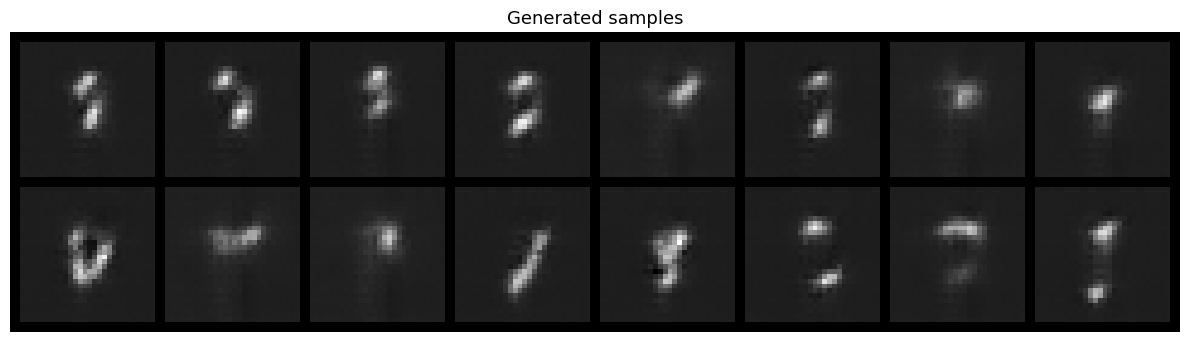

In [24]:
def show_grid(samples, nrow=8, title="Generated samples"):
    grid = torchvision.utils.make_grid(
        samples,
        nrow=nrow,
        normalize=True,  # rescales to [0, 1] across the whole grid
        padding=2,
    )
    np_grid = grid.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(figsize=(min(nrow * 1.5, 16), max(2, len(samples) // nrow * 1.5 + 1)))
    ax.imshow(np_grid, cmap='gray')
    ax.set_title(title, fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

output = trainer.sample_annealed(
    shape=(16,1,28,28),
    steps_per_landscape=10,
    step_size=0.025,
    condition=torch.full((16,), 8, device="cuda")
)
print(output.shape)

show_grid(output.cpu())